# Data process

## Load Data

In [9]:
from t_dev_810.config import Config, PROCESS_TYPE, MODEL_TYPE, DatasetPaths
import matplotlib.pyplot as plt
from t_dev_810.utils.utils import cropping, init_dataset, enhance_contrast, register_processed_images, display_distribution
from PIL import Image
from t_dev_810.utils.results import dataset_process_register
from t_dev_810.utils.model import ImageFile


config = Config(PROCESS=[PROCESS_TYPE.data_distribution, PROCESS_TYPE.normalize_img ],PROCESSED=[], MESSAGE="try to limit overfitting with smallest image size and only splitting test and val set", IMG_SIZE=(128, 128), MODEL=MODEL_TYPE.logistic_regression)
dataset_paths = DatasetPaths.load()

X_train = [ImageFile(Image.open(dataset_paths).convert("L"), dataset_paths) for dataset_paths in dataset_paths.train_normal_paths + dataset_paths.train_pneumonia_paths]
X_test = [ImageFile(Image.open(dataset_paths).convert("L"), dataset_paths) for dataset_paths in dataset_paths.test_normal_paths + dataset_paths.test_pneumonia_paths]
X_val = [ImageFile(Image.open(dataset_paths).convert("L"), dataset_paths) for dataset_paths in dataset_paths.val_normal_paths + dataset_paths.val_pneumonia_paths]

init_dataset()



## Normalize image size

In [10]:
assert PROCESS_TYPE.normalize_img in config.PROCESS
config.PROCESSED.append(PROCESS_TYPE.normalize_img)
X_train = [ImageFile(img_file.img.resize(config.IMG_SIZE), img_file.path) for img_file in X_train]
X_val = [ImageFile(img_file.img.resize(config.IMG_SIZE), img_file.path) for img_file in X_val]
X_test = [ImageFile(img_file.img.resize(config.IMG_SIZE), img_file.path) for img_file in X_test]

# Croping

In [11]:
if PROCESS_TYPE.img_cropping in config.PROCESS:
    config.PROCESSED.append(PROCESS_TYPE.img_cropping)
    X_train = [cropping(img) for img in X_train]
    X_test = [cropping(img) for img in X_test]
    X_val = [cropping(img) for img in X_val]

    plt.imshow(X_train[0].img, cmap="gray")
    plt.axis("off")
    plt.show()

## Enhance

In [12]:
if PROCESS_TYPE.enhance_color in config.PROCESS:
    config.PROCESSED.append(PROCESS_TYPE.enhance_color)
    X_train = enhance_contrast(X_train, config.ENHANCE_COLOR_FACTOR)
    X_val = enhance_contrast(X_val, config.ENHANCE_COLOR_FACTOR)
    X_test = enhance_contrast(X_test, config.ENHANCE_COLOR_FACTOR)

## Distribution

In [13]:
from t_dev_810.utils.splitting import data_splitting

if PROCESS_TYPE.data_distribution in config.PROCESS:
    X_train, X_val = data_splitting(config, X_train, X_val)

# Register

In [14]:
register_processed_images(X_train, "train")
register_processed_images(X_test, "test")
register_processed_images(X_val, "val")


dataset_process_register(config)

# Visualize

## Data distribution

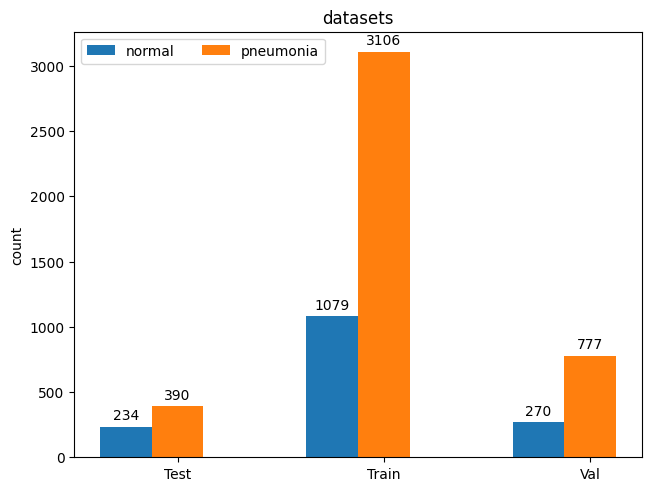

In [15]:
config = DatasetPaths.load_from_dataset(path=".")
display_distribution(config.test_normal_paths, config.test_pneumonia_paths, config.train_normal_paths, config.train_pneumonia_paths, config.val_normal_paths, config.val_pneumonia_paths)

## Data Image

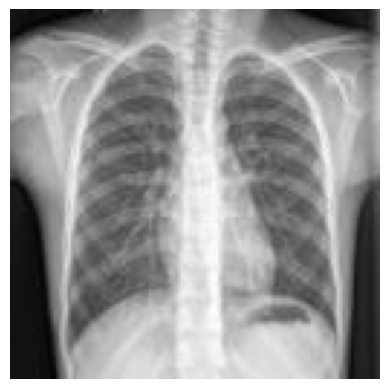

In [16]:

    img = Image.open(config.test_normal_paths[0])
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.show()